P1 - 6 - Cavidade 1D

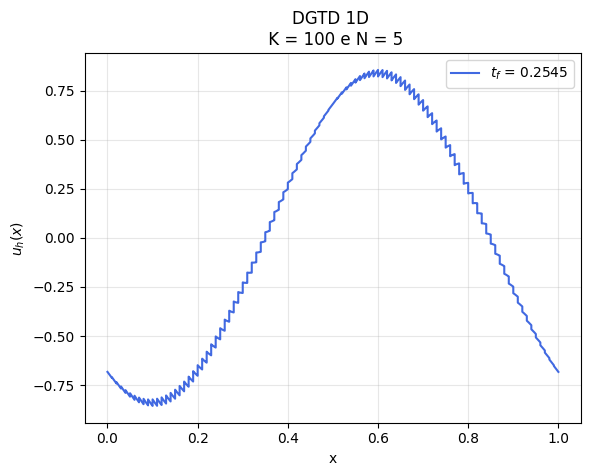

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import lsrk4 as rk4
import gll1D as gll
import operadores as op
import fluxo_numerico as fn

a = 1
kx = 2*np.pi
Nt = 700

xi = 0.0
xf = 1.0
K = 100
N = 5 

x, fronteiras = gll.gerar_malha_gll_1d(xi, xf, K, N)
dx = fronteiras[1:] - fronteiras[:-1]
u = np.sin(kx*x)

dt = 0.4 * ( (1/(2*N +1)) * (np.min(dx)/a)  )

nos_ref, _ = gll.pontos_gll(N)
V = op.matriz_vandermonde(N,nos_ref)
D = op.matriz_diferenciacao(N,nos_ref,V)

M_referencia = np.linalg.inv(np.dot(V, V.T))
M_ref_inv = np.linalg.inv(M_referencia)

fator_geometrico = (2/dx)

S_referencia = np.dot(M_referencia, D)

def residuo(u, D, M_inv, a, fator):
    # Teste de isolamento: ignora o fluxo temporariamente
    termo_volume = -a * (D @ u) * fator
    return termo_volume


for n in range(Nt):

    #u = rk4.lsrk4_passo(u,residuo(D,u,M_ref_inv,F,fator_geometrico),dt)
    u = rk4.lsrk4_passo(u, lambda u_atual: residuo(u_atual, D, M_ref_inv, a, fator_geometrico), dt)

    #u[:,0] = u[:,-1]

plt.figure()
plt.title(f'DGTD 1D \n K = {K} e N = {N}')
plt.ylabel(r'$u_h(x)$')
plt.xlabel('x')
plt.grid(alpha=0.3)
#plt.plot(x[0,:],u[0,:],color='royalblue',label=r'$t_f$ ='f'{Nt*dt:.1f}')
plt.plot(x.flatten('F'), u.flatten('F'), color='royalblue', label=f'$t_f$ = {Nt*dt:.4f}')
plt.legend()
plt.show()